In [1]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D

from qutip import *
import numpy as np

# from tomo_plot_hammer import *

# Find Classical Scars

In [2]:
# ---------- Utilities ----------
def normalize(v): return v/np.linalg.norm(v)

def sph_to_cart(theta, phi):
    return np.array([np.sin(theta)*np.cos(phi),
                     np.sin(theta)*np.sin(phi),
                     np.cos(theta)])

def cart_to_sph(v):
    v = normalize(v)
    theta = np.arccos(np.clip(v[2],-1,1))
    phi = np.arctan2(v[1], v[0])   # stays in [-pi, pi]
    return theta, phi

def geodesic_angle(u,v):
    u=normalize(u); v=normalize(v)
    dot=np.clip(np.dot(u,v),-1,1)
    return np.arccos(dot)

def R_y(alpha):
    c,s=np.cos(alpha),np.sin(alpha)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]])

def R_z(beta):
    c,s=np.cos(beta),np.sin(beta)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]])

def spherical_angles(v):
    x, y, z = v[...,0], v[...,1], v[...,2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return phi, theta

# ---------- Generalized kicked-top ----------
def kicked_top_step_general(v,kappa,alpha,order):
    z=v[2]
    angle=kappa*np.sign(z)*(abs(z)**(order-1))
    v1=R_z(-angle)@v
    v2=R_y(-alpha)@v1
    return normalize(v2)

def poincare_section_general(k, p=np.pi/2, order=2,
                             n_seeds_phi=12, n_seeds_theta=12,
                             n_iter=1500, n_discard=100):
    """
    Generate a Poincaré section (phi, theta) for the generalized kicked top.
    """
    phis = np.linspace(-np.pi, np.pi, n_seeds_phi, endpoint=False)
    thetas = np.linspace(0.15*np.pi, 0.85*np.pi, n_seeds_theta)

    # phis = [-0.289]
    # thetas = [1.174]

    seeds = []
    for th in thetas:
        for ph in phis:
            seeds.append(np.array([np.cos(ph)*np.sin(th),
                                   np.sin(ph)*np.sin(th),
                                   np.cos(th)]))
    v = np.stack(seeds, axis=0)

    pts_phi, pts_theta = [], []
    for i in range(n_iter):
        # loop explicitly over all seeds
        v = np.array([kicked_top_step_general(vi, k, p, order) for vi in v])
        if i >= n_discard:
            for vi in v:
                ph, th = spherical_angles(vi)   # single vector
                pts_phi.append(ph)
                pts_theta.append(th)

    return np.array(pts_phi), np.array(pts_theta)

# ---------- Find Classical Scars ----------
def F_p(v,kappa,alpha,order,p):
    out=normalize(v)
    for _ in range(p):
        out=kicked_top_step_general(out,kappa,alpha,order)
    return normalize(out)

def residual(v,kappa,alpha,order,p):
    return F_p(v,kappa,alpha,order,p)-normalize(v)

def numerical_jacobian(v,kappa,alpha,order,p,eps=1e-6):
    J=np.zeros((3,3))
    for j in range(3):
        e=np.zeros(3); e[j]=1
        f_plus =F_p(normalize(v+eps*e),kappa,alpha,order,p)
        f_minus=F_p(normalize(v-eps*e),kappa,alpha,order,p)
        J[:,j]=(f_plus-f_minus)/(2*eps)
    return J

def refine_orbit(v0,kappa,alpha,order,p,maxit=50,tol=1e-12):
    v=normalize(v0)
    for _ in range(maxit):
        r=residual(v,kappa,alpha,order,p)
        if np.linalg.norm(r)<tol: return normalize(v),True
        J=numerical_jacobian(v,kappa,alpha,order,p)
        A=J-np.eye(3)
        try: delta=np.linalg.solve(A,r)
        except np.linalg.LinAlgError: return normalize(v),False
        v=normalize(v-delta)
    return normalize(v),np.linalg.norm(residual(v,kappa,alpha,order,p))<tol

def deduplicate(points,angle_tol=1e-3):
    uniq=[]
    for v in points:
        if all(geodesic_angle(v,u)>angle_tol for u in uniq):
            uniq.append(v)
    return uniq

def find_period_p_orbits(kappa,alpha,order,p,
                         grid_th=41,grid_ph=81,
                         seed_tol=5e-2,refine_tol=1e-10):
    # grid seeds
    thetas=np.linspace(0,np.pi,grid_th)
    phis=np.linspace(-np.pi,np.pi,grid_ph)
    seeds=[]
    for th in thetas:
        for ph in phis:
            v0=sph_to_cart(th,ph)
            if np.linalg.norm(residual(v0,kappa,alpha,order,p))<seed_tol:
                seeds.append(v0)
    # refine
    refined=[]
    for s in seeds:
        v_ref,ok=refine_orbit(s,kappa,alpha,order,p,tol=refine_tol)
        if ok: refined.append(v_ref)
    uniq=deduplicate(refined,angle_tol=1e-3)
    # build cycles
    cycles=[]; used=[False]*len(uniq)
    for i,v in enumerate(uniq):
        if used[i]: continue
        orb=[v]; cur=v
        for _ in range(1,p):
            cur=kicked_top_step_general(cur,kappa,alpha,order)
            j_best,ang_best=None,1e9
            for j,u in enumerate(uniq):
                ang=geodesic_angle(cur,u)
                if ang<ang_best: ang_best, j_best=ang,j
            if ang_best<1e-2:
                orb.append(uniq[j_best]); used[j_best]=True
        if len(orb)==p: cycles.append(orb)
    return [[cart_to_sph(v) for v in cyc] for cyc in cycles]


In [4]:
%matplotlib widget

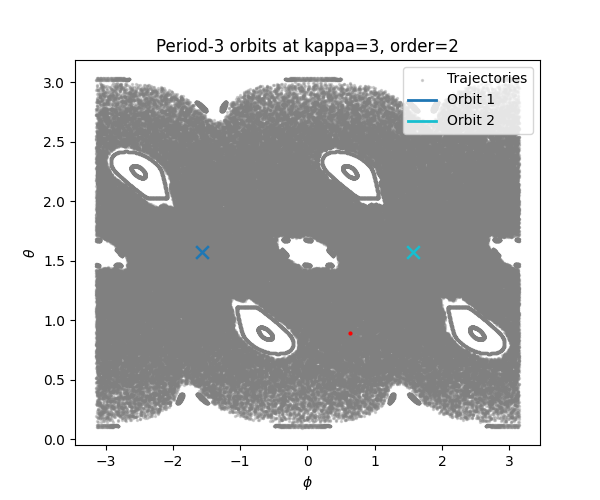

In [16]:
kappa=2.2; alpha=np.pi/2; order=2; period=3

kappa=3; alpha=np.pi/2; order=2; period=3

cycles=find_period_p_orbits(kappa,alpha,order,period)
phi_pts,theta_pts=poincare_section_general(kappa,alpha,order)

plt.figure(figsize=(6,5))
plt.scatter(phi_pts,theta_pts,c = 'gray', s=2,alpha=0.3,label='Trajectories')

colors=plt.cm.tab10(np.linspace(0,1,len(cycles)))
for ic,cyc in enumerate(cycles):
    phs=[ph for th,ph in cyc]; ths=[th for th,ph in cyc]
    plt.scatter(phs,ths,c=[colors[ic]],marker='x',s=80)
    plt.plot(phs+[phs[0]],ths+[ths[0]],color=colors[ic],alpha=1,
             label=f'Orbit {ic+1}', linewidth = 2)

plt.xlabel(r'$\phi$'); plt.ylabel(r'$\theta$')
plt.title(f"Period-{period} orbits at kappa={kappa}, order={order}")
plt.legend()

plt.plot(0.625, np.pi-2.25, marker='o', color='red', markersize=2)
# plt.savefig('Poincare_map.jpg')
plt.show()

In [4]:
print(f"Found {len(cycles)} period-{period} orbits")
for i,cyc in enumerate(cycles,1):
    print(f"Orbit {i}:")
    for th,ph in cyc:
        print(f"  theta={th:.3f}, phi={ph:.3f}")

Found 6 period-3 orbits
Orbit 1:
  theta=0.486, phi=-0.598
  theta=1.967, phi=-2.852
  theta=1.967, phi=-1.139
Orbit 2:
  theta=1.174, phi=-2.003
  theta=2.655, phi=-2.543
  theta=1.174, phi=-0.289
Orbit 3:
  theta=0.785, phi=-1.571
  theta=2.356, phi=-3.126
  theta=1.571, phi=-0.785
Orbit 4:
  theta=0.785, phi=-0.015
  theta=1.571, phi=-2.356
  theta=2.356, phi=-1.571
Orbit 5:
  theta=1.571, phi=-1.571
  theta=1.571, phi=-1.571
  theta=1.571, phi=-1.571
Orbit 6:
  theta=1.571, phi=1.571
  theta=1.571, phi=1.571
  theta=1.571, phi=1.571


# Quantum scars

# Floquet eigenstates 

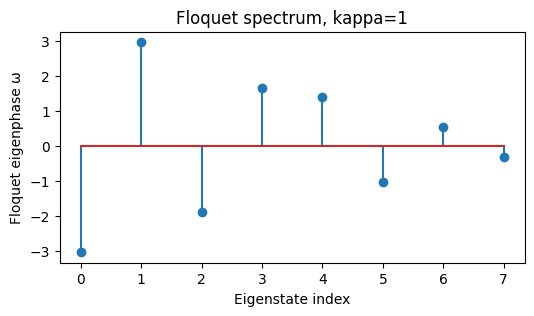

In [16]:
# --- parameters ---
J = 7/2
dim = int(2*J + 1)
kappa = 1
alpah = np.pi / 2

# --- spin operators ---
Jx = jmat(J, 'x')
Jy = jmat(J, 'y')
Jz = jmat(J, 'z')

# --- Floquet operator ---
U = (-1j * (kappa/(2*J)) * Jz**2).expm() * (-1j * alpah * Jy).expm()
eigvals, eigvecs = U.eigenstates()

phases = np.angle(eigvals)
phases = np.mod(phases + np.pi, 2*np.pi) - np.pi  # map to [-π, π]
plt.figure(figsize=(6,3))
plt.stem(range(dim), phases)
plt.ylabel("Floquet eigenphase ω")
plt.xlabel("Eigenstate index")
plt.title(f"Floquet spectrum, kappa={kappa}")
plt.show()

Eigenphase differences (radians):
[1.162 0.839 0.732 0.839 0.866 0.275 1.296 0.275]
Sector 0: [-3.043  2.966]
Sector 1: [-1.881 -1.042]
Sector 2: [-0.31   0.529]
Sector 3: [1.395 1.67 ]


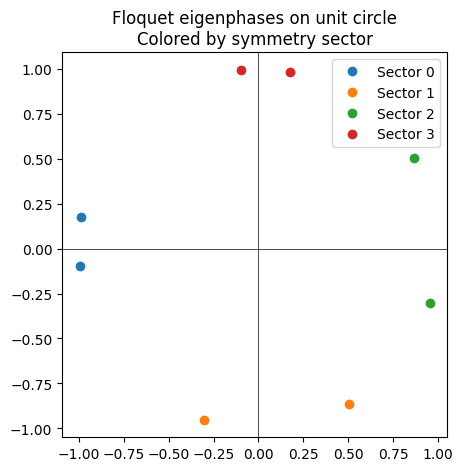

In [17]:
# Sort eigenphases for clarity
sorted_idx = np.argsort(phases)
sorted_phases = phases[sorted_idx]

# Compute differences mod 2π
diffs = np.diff(np.concatenate((sorted_phases, [sorted_phases[0] + 2*np.pi])))
print("Eigenphase differences (radians):")
print(np.round(diffs, 3))

# --- Group eigenphases roughly every π/2 ---
tol = 0.4  # tolerance for grouping
groups = [[] for _ in range(4)]
ref_phase = sorted_phases[0]
for ph in sorted_phases:
    # compute how many π/2 steps away (rounded)
    step = int(np.round(((ph - ref_phase) % (2*np.pi)) / (np.pi/2))) % 4
    groups[step].append(ph)

# Print the groups
for i, g in enumerate(groups):
    print(f"Sector {i}: {np.round(g, 3)}")

plt.figure(figsize=(5,5))
colors = ['C0','C1','C2','C3']
for i, g in enumerate(groups):
    for ph in g:
        plt.plot(np.cos(ph), np.sin(ph), 'o', color=colors[i], label=f"Sector {i}" if ph==g[0] else "")
plt.gca().set_aspect('equal')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.legend()
plt.title("Floquet eigenphases on unit circle\nColored by symmetry sector")
plt.show()

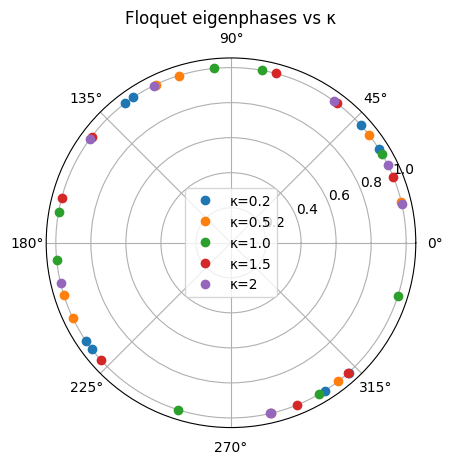

In [20]:
for kappa in [0.2, 0.5, 1.0, 1.5, 2]:
    U = (-1j*(kappa/(2*J))*Jz**2).expm() * (-1j*alpha*Jy).expm()
    eigvals, _ = U.eigenstates()
    phases = np.angle(eigvals)
    plt.polar(phases, np.ones_like(phases), 'o', label=f'κ={kappa}')
plt.legend()
plt.title("Floquet eigenphases vs κ")
plt.show()

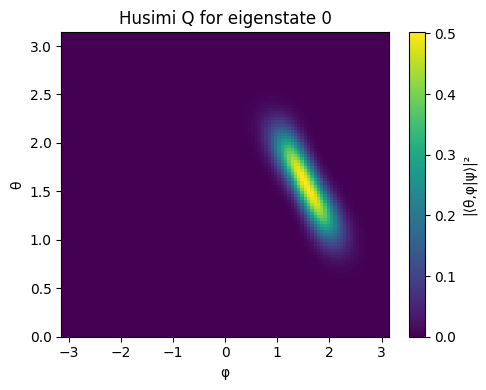

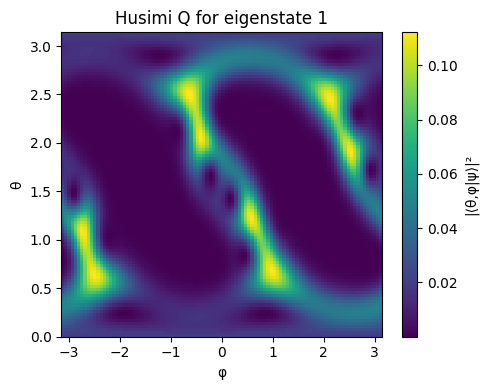

KeyboardInterrupt: 

In [9]:
# Husimi plot Floquet eigenstates
def husimi(psi, res=200):
    theta = np.linspace(0, np.pi, res)
    phi = np.linspace(-np.pi, np.pi, res)
    Q = np.zeros((res, res))
    for i, th in enumerate(theta):
        for j, ph in enumerate(phi):
            coh = spin_coherent(J, th, ph)
            Q[i,j] = abs(coh.overlap(psi))**2
    return theta, phi, Q

# pick a few eigenstates to inspect
idx_list = [0, 1, 2, 3, 4, 5, 6, 7]

# # Hammer Projections
# for idx in idx_list:
#     fig = tomo_plot_hammer(eigvecs[idx],'h')

for idx in idx_list:
    psi = eigvecs[idx]
    theta, phi, Q = husimi(psi, res=100)
    plt.figure(figsize=(5,4))
    plt.imshow(Q, extent=[-np.pi, np.pi, 0, np.pi], origin='lower', aspect='auto')
    plt.xlabel("φ")
    plt.ylabel("θ")
    plt.title(f"Husimi Q for eigenstate {idx}")
    plt.colorbar(label="|⟨θ,φ|ψ⟩|²")
    plt.tight_layout()
    plt.show()

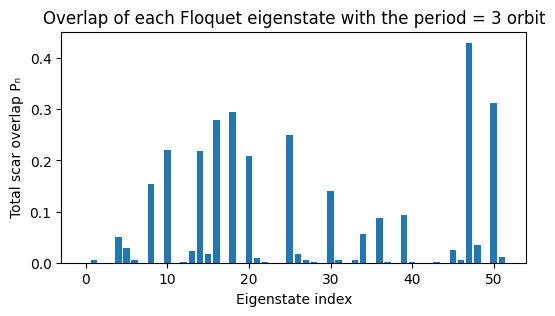

Highest-overlap eigenstate indices: [47 50 18 16 25 10 14 20  8 30 39 36 34  4 48  5 45 13 15 26 51 21  1  6
 27 31 46 33 28 22 12 37 40 43 29 42 38 44 17  9  2 49  7 35 24 23 19 11
 41  0  3 32]
Largest overlap at eigenstate index 47


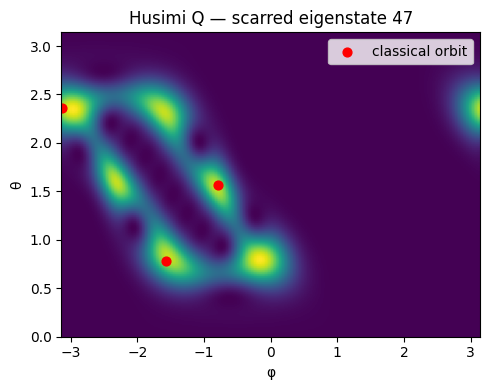

In [11]:
# Find the overlap between the Floquet eigenstates with classical orbit points (θ, φ)
orbit_points = cycles[2]

coh_states = [spin_coherent(J, th, ph) for th, ph in orbit_points]

P = np.zeros(dim)
for n, psi in enumerate(eigvecs):
    overlaps = [abs(coh.overlap(psi))**2 for coh in coh_states]
    P[n] = np.sum(overlaps)

plt.figure(figsize=(6,3))
plt.bar(range(dim), P)
plt.xlabel("Eigenstate index")
plt.ylabel("Total scar overlap Pₙ")
plt.title(f"Overlap of each Floquet eigenstate with the period = {period} orbit")


plt.show()

print("Highest-overlap eigenstate indices:", np.argsort(P)[::-1])

scar_idx = int(np.argmax(P))
print(f"Largest overlap at eigenstate index {scar_idx}")
psi_scar = eigvecs[scar_idx]

theta, phi, Q = husimi(psi_scar, res=150)
plt.figure(figsize=(5,4))
plt.imshow(Q, extent=[-np.pi, np.pi, 0, np.pi], origin='lower', aspect='auto')
plt.scatter([ph for th, ph in orbit_points],
            [th for th, ph in orbit_points],
            color='red', s=40, label='classical orbit')
plt.xlabel("φ")
plt.ylabel("θ")
plt.title(f"Husimi Q — scarred eigenstate {scar_idx}")
plt.legend()
plt.tight_layout()
plt.show()

# Quantum evolution

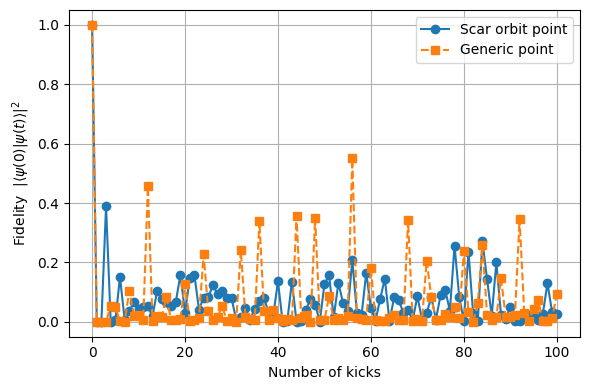

In [12]:
# number of kicks to simulate
Nsteps = 100

# storage for fidelity
F = np.zeros(Nsteps+1)
F[0] = 1.0   # at t=0, F=1

# initialize to one of the scar
psi0 = spin_coherent(J, orbit_points[0][0], orbit_points[0][1])
psi_t = psi0

for n in range(1, Nsteps+1):
    psi_t = U * psi_t       # apply one Floquet period
    F[n] = abs(psi0.overlap(psi_t))**2


# Another non-scar state for comparison
theta_rand, phi_rand = 0.5*np.pi, 0.1*np.pi
psi_rand = spin_coherent(J, theta_rand, phi_rand)
F_rand = np.zeros(Nsteps+1)
F_rand[0] = 1.0
psi_t = psi_rand
for n in range(1, Nsteps+1):
    psi_t = U * psi_t
    F_rand[n] = abs(psi_rand.overlap(psi_t))**2

plt.figure(figsize=(6,4))
plt.plot(F, 'o-', label='Scar orbit point')
plt.plot(F_rand, 's--', label='Generic point')
plt.xlabel("Number of kicks")
plt.ylabel("Fidelity  $|⟨ψ(0)|ψ(t)⟩|^2$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

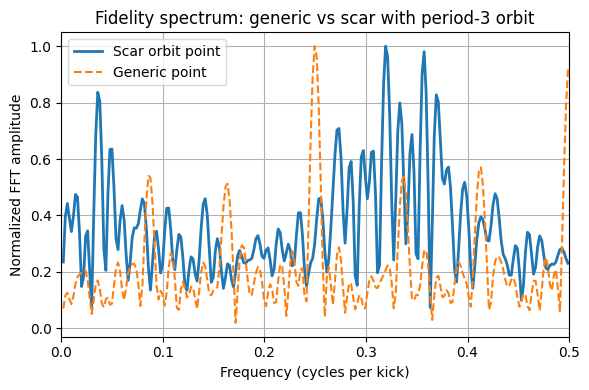

Scarred point dominant freq ≈ 0.319 → period ≈ 3.13 kicks
Generic point dominant freq ≈ 0.250 → period ≈ 4.01 kicks


In [13]:
# --- FFT analysis of fidelity traces ---

def plot_fft(F, F_rand, Nsteps):
    # Remove DC offsets
    F_c = F - np.mean(F)
    F_r = F_rand - np.mean(F_rand)

    # Zero-padding for better frequency resolution
    pad = 4 * Nsteps
    F_c_pad = np.pad(F_c, (0, pad), 'constant')
    F_r_pad = np.pad(F_r, (0, pad), 'constant')

    # FFT and frequency axis
    fft_c = np.fft.fft(F_c_pad)
    fft_r = np.fft.fft(F_r_pad)
    freqs = np.fft.fftfreq(len(F_c_pad), d=1)

    # Only keep positive frequencies
    mask = freqs > 0
    freqs = freqs[mask]
    spec_c = np.abs(fft_c[mask])
    spec_r = np.abs(fft_r[mask])

    # Normalize for visual comparison
    spec_c /= spec_c.max()
    spec_r /= spec_r.max()

    # --- Plot ---
    plt.figure(figsize=(6,4))
    plt.plot(freqs, spec_c, label='Scar orbit point', lw=2)
    plt.plot(freqs, spec_r, '--', label='Generic point', lw=1.5)
    plt.xlabel("Frequency (cycles per kick)")
    plt.ylabel("Normalized FFT amplitude")
    plt.title(f"Fidelity spectrum: generic vs scar with period-{period} orbit")
    plt.xlim(0, 0.5)         # only need up to Nyquist/2
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print dominant frequencies
    peak_c = freqs[np.argmax(spec_c)]
    peak_r = freqs[np.argmax(spec_r)]
    print(f"Scarred point dominant freq ≈ {peak_c:.3f} → period ≈ {1/peak_c:.2f} kicks")
    print(f"Generic point dominant freq ≈ {peak_r:.3f} → period ≈ {1/peak_r:.2f} kicks")

# Call the function
plot_fft(F, F_rand, Nsteps)